# 01 - Exploratory Data Analysis
**Dataset:** NHANES 2017-2018 (CDC)

**Goal:** Load and merge blood test, demographics, and diabetes data. Understand structure, quality and patterns relevent to diabetes risk prediction.

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_theme(style="whitegrid")

print("Libraries loaded")

Libraries loaded


### Load XPT Files

In [2]:
#NHANES files are in SAS XPT format, pandas read them natively
cbc = pd.read_sas("../data/CBC_J.xpt")
demo = pd.read_sas("../data/DEMO_J.xpt")
diq = pd.read_sas("../data/DIQ_J.xpt")
bmx = pd.read_sas('../data/BMX_J.XPT')

print(f"CBC Shape: {cbc.shape}")
print(f"DEMO Shape: {demo.shape}")
print(f"DIQ Shape: {diq.shape}")
print(f"BMX Shape: {bmx.shape}")

CBC Shape: (8366, 22)
DEMO Shape: (9254, 46)
DIQ Shape: (8897, 54)
BMX Shape: (8704, 21)


### Preview Each File

In [3]:
print("=== CBC (BLood Count) ===")
display(cbc.head(3))

print("=== DEMO (Demographics) ===")
display(demo.head(3))

print("=== DIQ (Diabetes) ===")
display(diq.head(3))

print("=== BMX (Body Measures) ===")
display(bmx.head(3))

=== CBC (BLood Count) ===


,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,...,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMCHSI,LBXMC,LBXRDW,LBXPLTSI,LBXMPSI,LBXNRBC
0,93703.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,7.4,47.8,8.0,42.6,1.0,0.7,3.5,0.6,3.2,...,4.25,13.1,37.0,87.0,30.8,35.4,12.8,239.0,8.6,1.000000e-01
2,93705.0,8.6,40.0,7.4,48.8,2.9,1.0,3.4,0.6,4.2,...,5.48,11.9,36.7,67.0,21.7,32.4,15.6,309.0,7.9,5.397605e-79


=== DEMO (Demographics) ===


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82


=== DIQ (Diabetes) ===


,SEQN,DIQ010,DID040,DIQ160,DIQ170,DIQ172,DIQ175A,DIQ175B,DIQ175C,DIQ175D,...,DIQ300D,DID310S,DID310D,DID320,DID330,DID341,DID350,DIQ350U,DIQ360,DIQ080
0,93703.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,2.0,NaN,2.0,2.0,2.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== BMX (Body Measures) ===


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,1.0,13.7,3.0,89.6,NaN,NaN,NaN,88.6,NaN,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,1.0,13.9,NaN,95.0,NaN,NaN,NaN,94.2,NaN,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,1.0,79.5,NaN,NaN,NaN,NaN,NaN,158.3,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN


### Selecting the Columns only we need

In [4]:
# CBC - blood test parameters
cbc_cols = ['SEQN',      # unique ID (merge key)
            'LBXWBCSI',  # White Blood Cell count
            'LBXRBCSI',  # Red Blood Cell count
            'LBXHGB',    # Hemoglobin
            'LBXHCT',    # Hematocrit
            'LBXMCVSI',  # Mean Corpuscular Volume
            'LBXPLTSI']  # Platelet count

# DEMO - demographics
demo_cols = ['SEQN',     # unique ID
             'RIDAGEYR', # Age
             'RIAGENDR'] # Gender

# BMX — body measures
bmx_cols = ['SEQN',
            'BMXBMI']

# DIQ - diabetes diagnosis (our target)
diq_cols = ['SEQN',
            'DIQ010']    # Doctor told you have diabetes? 1=Yes 2=No 3=Borderline

cbc_sel = cbc[cbc_cols]
demo_sel = demo[demo_cols]
bmx_sel = bmx[bmx_cols]
diq_sel = diq[diq_cols]

print("Columns selected")

Columns selected


### Merging all Three Files

In [5]:
df = cbc_sel.merge(demo_sel, on='SEQN', how='inner')
df = df.merge(bmx_sel, on='SEQN', how='inner')
df = df.merge(diq_sel, on='SEQN', how='inner')

print(f"Merged dataset shape: {df.shape}")
df.head()

Merged dataset shape: (8366, 11)


,SEQN,LBXWBCSI,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXPLTSI,RIDAGEYR,RIAGENDR,BMXBMI,DIQ010
0,93703.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,17.5,2.0
1,93704.0,7.4,4.25,13.1,37.0,87.0,239.0,2.0,1.0,15.7,2.0
2,93705.0,8.6,5.48,11.9,36.7,67.0,309.0,66.0,2.0,31.7,2.0
3,93706.0,6.1,5.24,16.3,47.0,89.7,233.0,18.0,1.0,21.5,2.0
4,93707.0,11.2,5.02,14.5,42.1,83.9,348.0,13.0,1.0,18.1,2.0


### Renaming columns to Readable names

In [6]:
df = df.rename(columns={
    'LBXWBCSI': 'WBC',
    'LBXRBCSI': 'RBC',
    'LBXHGB':   'Hemoglobin',
    'LBXHCT':   'Hematocrit',
    'LBXMCVSI': 'MCV',
    'LBXPLTSI': 'Platelets',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Gender',
    'BMXBMI':   'BMI',
    'DIQ010':   'Diabetes'
})

df = df.drop(columns=['SEQN'])
print("Columns Renamed")
print(df.columns.tolist())

Columns Renamed
['WBC', 'RBC', 'Hemoglobin', 'Hematocrit', 'MCV', 'Platelets', 'Age', 'Gender', 'BMI', 'Diabetes']


### Cleaning Target Variables

In [7]:
# Diabetes column: 1=Yes 2=No 3=Boderline 7/9=Refused/Unknown
print("Raw Diabetes value counts:")
print(df['Diabetes'].value_counts())

# Keep only Yes (1) and No (2) and drop borderline and unknowns
df = df[df['Diabetes'].isin([1.0, 2.0])]

# Convert to binary: 1=Diabetes, 0=No Diabetes
df['Diabetes'] = df['Diabetes'].map({1.0: 1, 2.0:0})

print("\nCleaned Diabetes value counts:")
print(df['Diabetes'].value_counts())
print(f"\nDiabetes rate: {round(df['Diabetes'].mean() * 100, 2)}%")

Raw Diabetes value counts:
Diabetes
2.0    7334
1.0     853
3.0     175
9.0       4
Name: count, dtype: int64

Cleaned Diabetes value counts:
Diabetes
0    7334
1     853
Name: count, dtype: int64

Diabetes rate: 10.42%


### Checking for Missing values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

            Missing Count  Missing %
WBC                   833      10.17
RBC                   833      10.17
Hemoglobin            833      10.17
Hematocrit            833      10.17
MCV                   833      10.17
Platelets             833      10.17
BMI                   359       4.39
Age                     0       0.00
Gender                  0       0.00
Diabetes                0       0.00


### Understanding our Target Variables

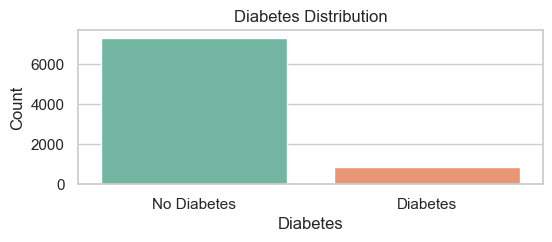

Class Imbalance Ratio: 8.6:1


In [9]:
diabetes_counts = df['Diabetes'].value_counts()

plt.figure(figsize=(6,2))
sns.countplot(x='Diabetes', data=df, palette='Set2', hue='Diabetes', legend=False)
plt.xticks([0,1], ['No Diabetes', 'Diabetes'])
plt.title("Diabetes Distribution")
plt.ylabel("Count")
plt.savefig('../data/diabetes_distribution.png', bbox_inches='tight')
plt.show()

print(f"Class Imbalance Ratio: {round(diabetes_counts[0]/diabetes_counts[1], 2)}:1")

### Age Distribution by Diabetes Status

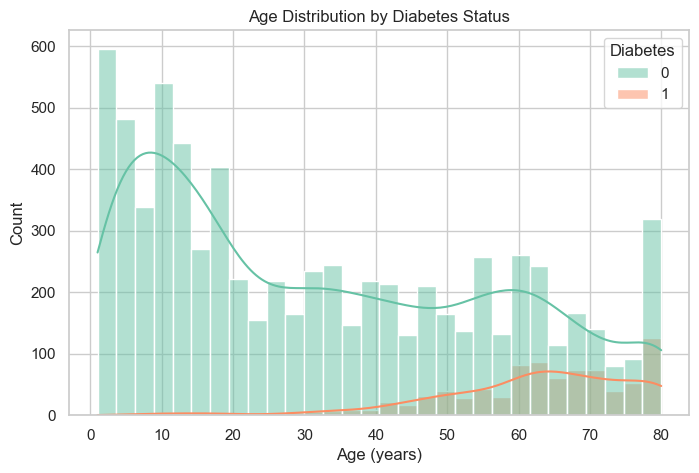

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Diabetes', kde=True, palette='Set2', bins=30)
plt.xlabel("Age (years)")
plt.title("Age Distribution by Diabetes Status")
plt.savefig('../data/age_vs_diabetes.png', bbox_inches='tight')
plt.show()

### BMI Distribution by Diabetes

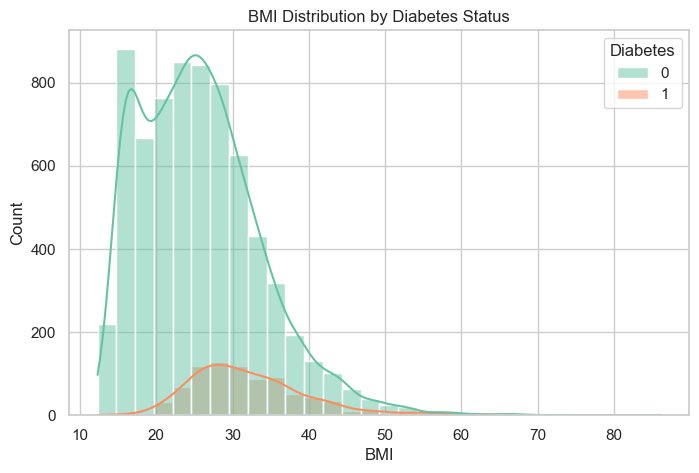

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='BMI', hue='Diabetes', kde=True, palette='Set2', bins=30)
plt.xlabel("BMI")
plt.title("BMI Distribution by Diabetes Status")
plt.savefig('../data/bmi_vs_diabetes.png', bbox_inches='tight')
plt.show()

### Blood Parameters vs Diabetes

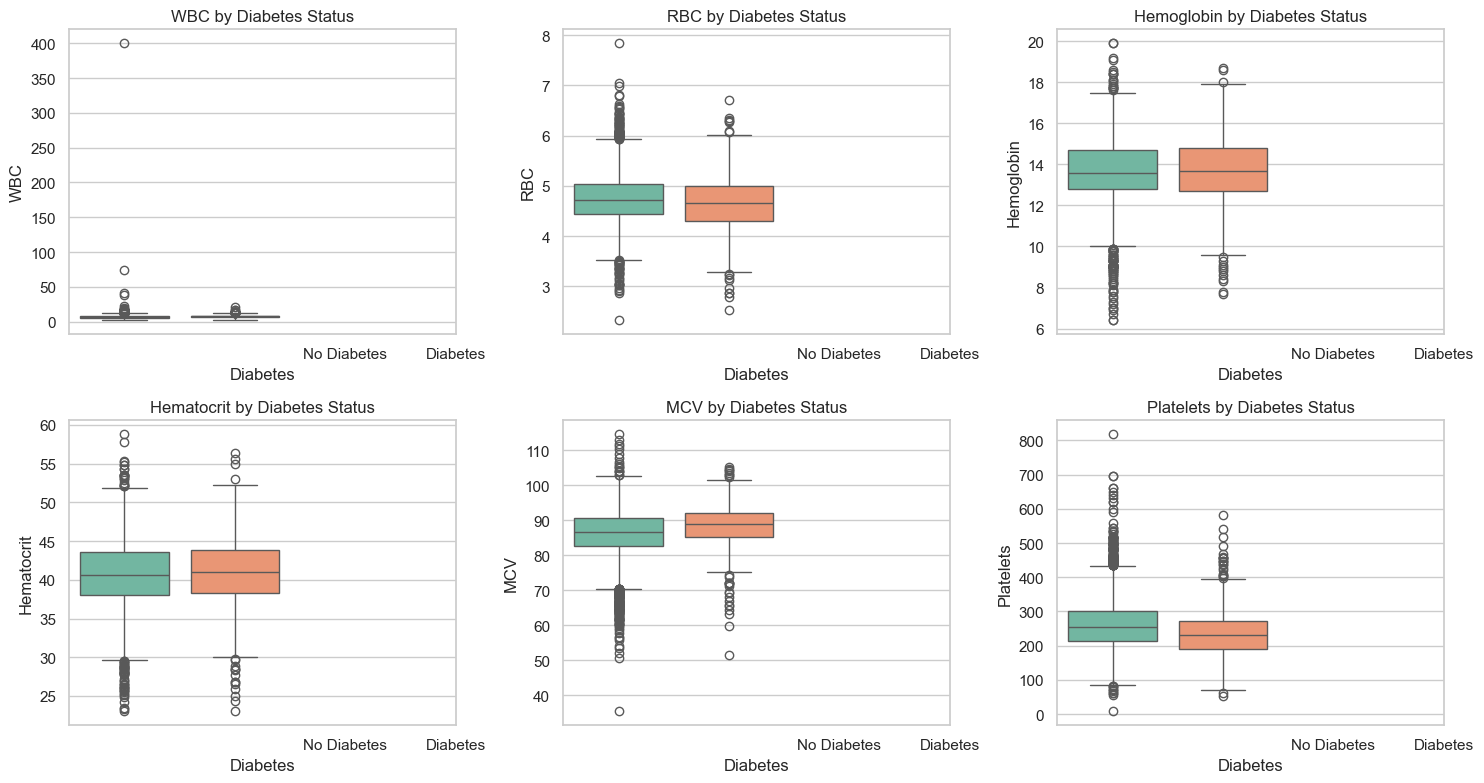

In [12]:
blood_cols = ['WBC', 'RBC', 'Hemoglobin', 'Hematocrit', 'MCV', 'Platelets']

fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(blood_cols):
    sns.boxplot(x='Diabetes', y=col, data=df, ax=axes[i], palette='Set2', hue='Diabetes', legend=False)
    axes[i].set_title(f"{col} by Diabetes Status")
    axes[i].set_xticks(['No Diabetes', 'Diabetes'])
    
plt.tight_layout()
plt.savefig('../data/blood_params_vs_diabetes.png', bbox_inches='tight')
plt.show()

### Correlation Heatmap

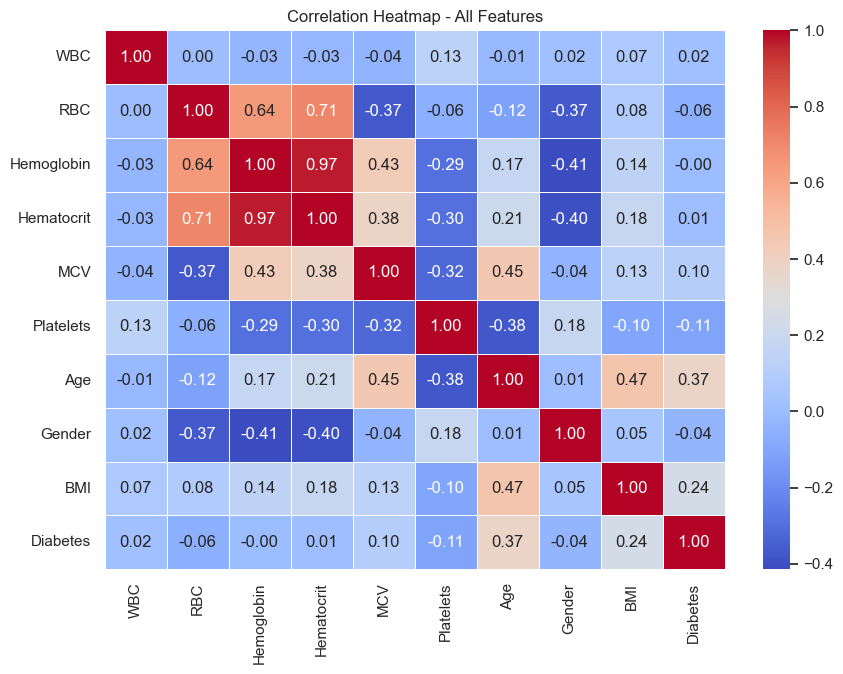

In [13]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - All Features")
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### Gender Distribution

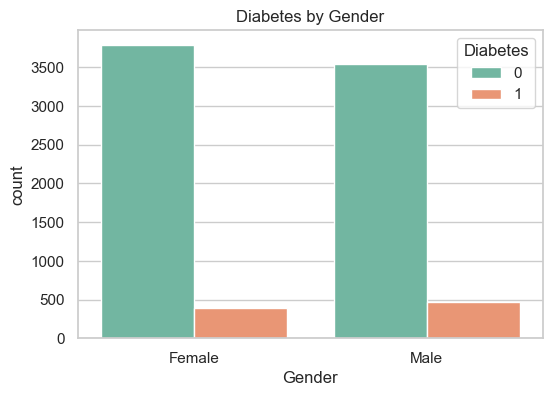

In [14]:
# Gender: 1 = Male, 2 = Female
df['Gender_label'] = df['Gender'].map({1.0: 'Male', 2.0: 'Female'})

plt.figure(figsize=(6,4))
sns.countplot(x='Gender_label', hue='Diabetes', data=df, palette='Set2')
plt.title("Diabetes by Gender")
plt.xlabel('Gender')
plt.savefig('../data/diabetes_by_gender.png', bbox_inches='tight')
plt.show()

## Key Findings from EDA

1. **Diabetes rate is 10.42%** — dataset is imbalanced (8.6:1 ratio), needs handling in modeling
2. **Age** — diabetic patients are significantly older, strong predictor
3. **BMI** — higher BMI strongly associated with diabetes, clinically validated
4. **Hemoglobin & Hematocrit** — show notable differences between groups
5. **WBC** — slightly elevated in diabetic group, consistent with inflammation markers
6. **Gender** — marginal difference, included but lower importance expected

## Domain Note (from lab experience)
> Elevated WBC in diabetic patients aligns with chronic low-grade inflammation 
> associated with Type 2 diabetes. Reduced Hemoglobin may indicate diabetic 
> nephropathy effects on erythropoiesis.

## Issues to Fix in Preprocessing (Notebook 02)
- Missing values in BMI and some blood parameters
- Gender needs to be encoded as binary 0/1
- Class imbalance (10.42% diabetic) needs SMOTE or class_weight handling

In [15]:
df.to_csv('../data/nhanes_after_eda.csv', index=False)
print(f"Saved: {df.shape}")

Saved: (8187, 11)
